In [ ]:
#import the libraries
import pandas as pd
import matplotlib.pyplot as plt

# load cleaned dataset
qld = pd.read_excel("QLD_clean.xlsx")

# check the first few rows and column names
print(qld.head())
print(qld.columns)


           Datetime  Total Demand    RRP Precipitation (mm)  Air Temp (C)  \
0  2000/01/01 00:30    3905.56833  39.40                  0          22.0   
1  2000/01/01 01:00    3855.67500  34.18                  0          21.7   
2  2000/01/01 01:30    3814.44667  35.20                  0          21.4   
3  2000/01/01 02:00    3705.36500  25.53                  0          21.5   
4  2000/01/01 02:30    3615.71333  18.55                  0          21.3   

   Humidity (%)  Wind Speed (km/h)  
0            75               13.0  
1            78               11.2  
2            82               11.2  
3            83                9.4  
4            82               11.2  
Index(['Datetime', 'Total Demand', 'RRP', 'Precipitation (mm)', 'Air Temp (C)',
       'Humidity (%)', 'Wind Speed (km/h)'],
      dtype='object')


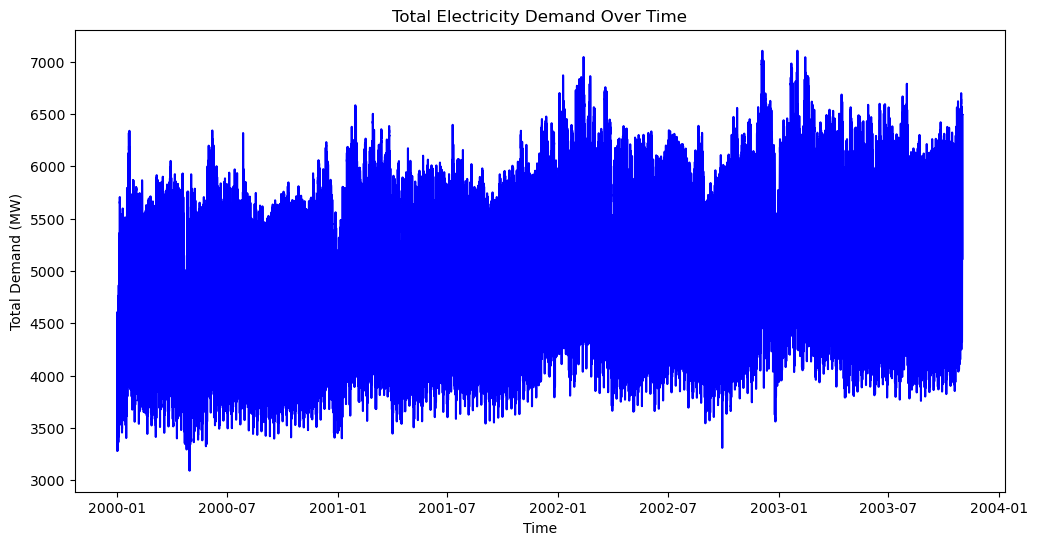

In [ ]:
# plot time series 
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Total Demand'], color='blue')
plt.title("Total Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Total Demand (MW)")
plt.show()



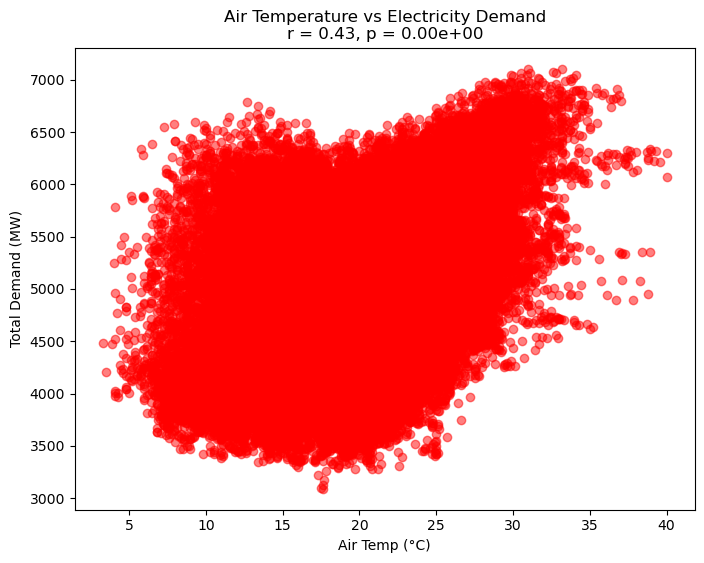

In [ ]:
# plot scatterplot of air temperature vs electricity demand
from scipy.stats import pearsonr

r, p = pearsonr(df['Air Temp (C)'], df['Total Demand'])

plt.figure(figsize=(8,6))
plt.scatter(df['Air Temp (C)'], df['Total Demand'], alpha=0.5, color='red')
plt.title(f"Air Temperature vs Electricity Demand\nr = {r:.2f}, p = {p:.2e}")
plt.xlabel("Air Temp (°C)")
plt.ylabel("Total Demand (MW)")
plt.show()



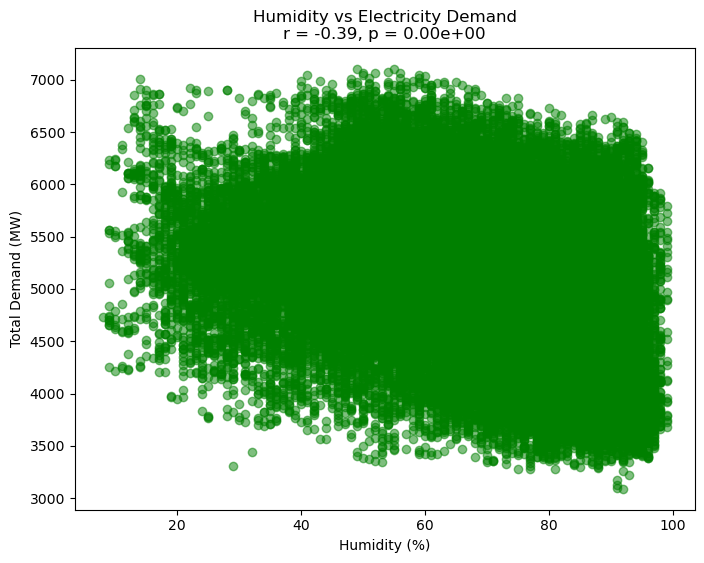

In [ ]:
# plot scatterplot of humidity vs electricity demand
r, p = pearsonr(df['Humidity (%)'], df['Total Demand'])

plt.figure(figsize=(8,6))
plt.scatter(df['Humidity (%)'], df['Total Demand'], alpha=0.5, color='green')
plt.title(f"Humidity vs Electricity Demand\nr = {r:.2f}, p = {p:.2e}")
plt.xlabel("Humidity (%)")
plt.ylabel("Total Demand (MW)")
plt.show()


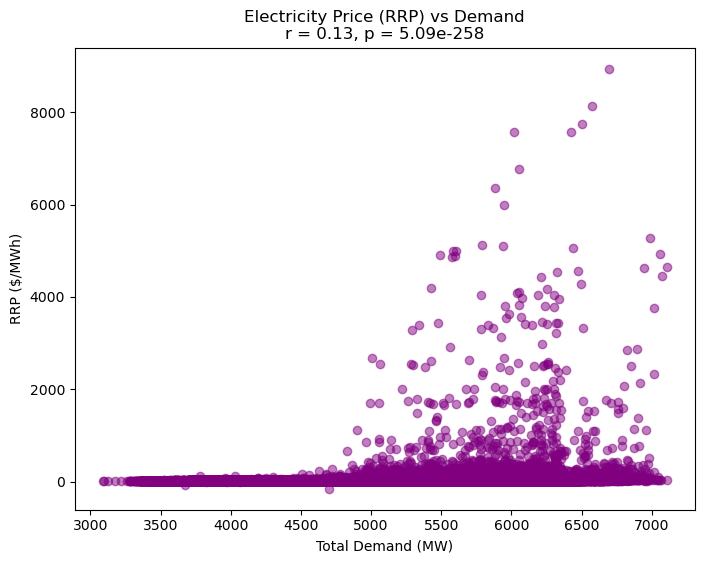

In [ ]:
# plot scatterplot of electricity price vs demand
r, p = pearsonr(df['Total Demand'], df['RRP'])

plt.figure(figsize=(8,6))
plt.scatter(df['Total Demand'], df['RRP'], alpha=0.5, color='purple')
plt.title(f"Electricity Price (RRP) vs Demand\nr = {r:.2f}, p = {p:.2e}")
plt.xlabel("Total Demand (MW)")
plt.ylabel("RRP ($/MWh)")
plt.show()


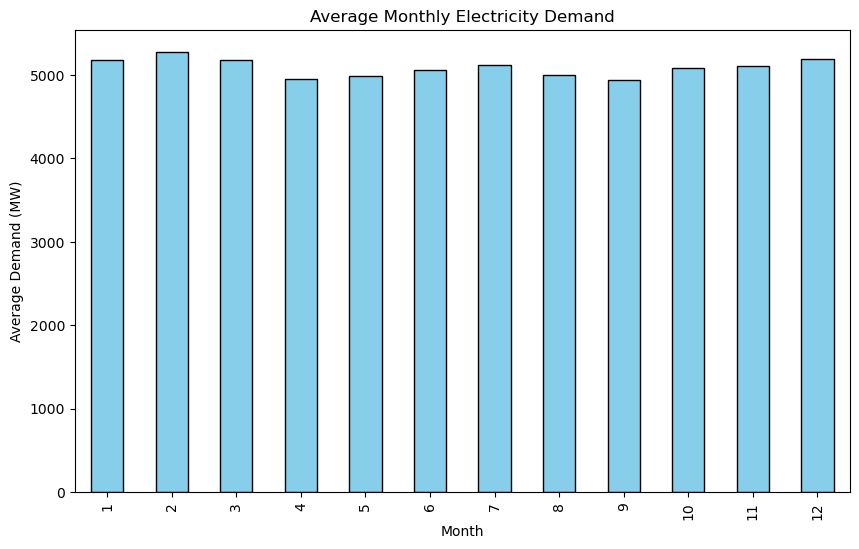

In [ ]:
# plot bar graph of average monthly electricity demand
plt.figure(figsize=(10,6))
monthly_demand = df.groupby(df.index.month)['Total Demand'].mean()
monthly_demand.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Average Monthly Electricity Demand")
plt.xlabel("Month")
plt.ylabel("Average Demand (MW)")
plt.show()


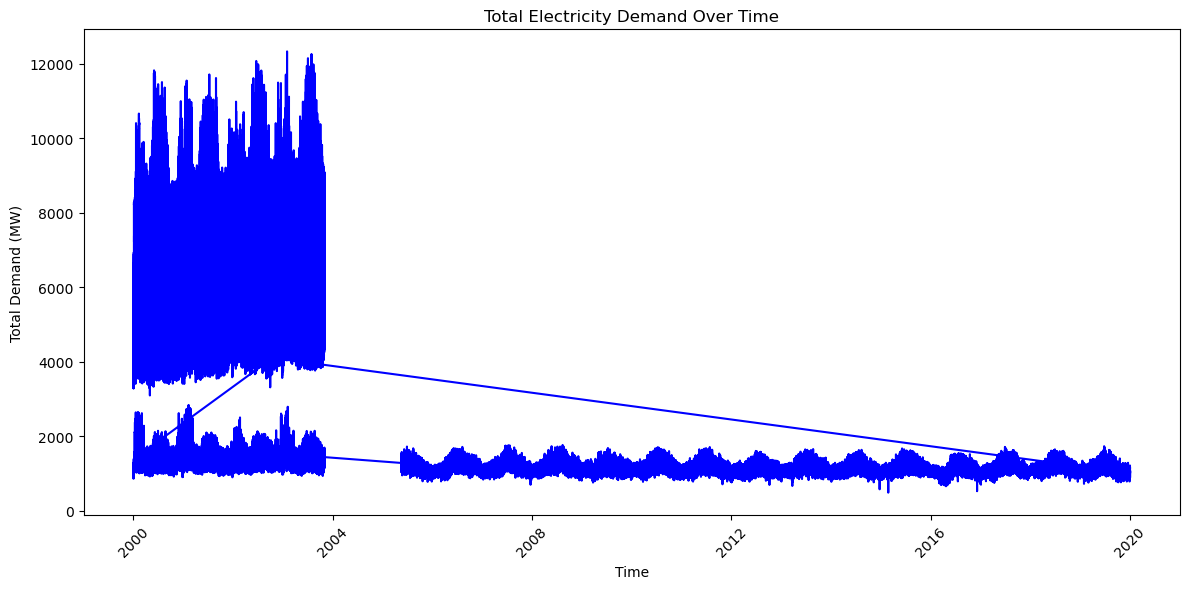

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# load dataset and parse datetime column on load
df = pd.read_csv(
    r"C:\Users\harja\Downloads\Datasets for temperature and energy demand modelling-20250729\master_data.csv",
    parse_dates=['Datetime']
)

# plot time series graph for total electricity demand over time 
plt.figure(figsize=(12,6))
plt.plot(df['Datetime'], df['Total Demand'], color='blue')
plt.title("Total Electricity Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Total Demand (MW)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



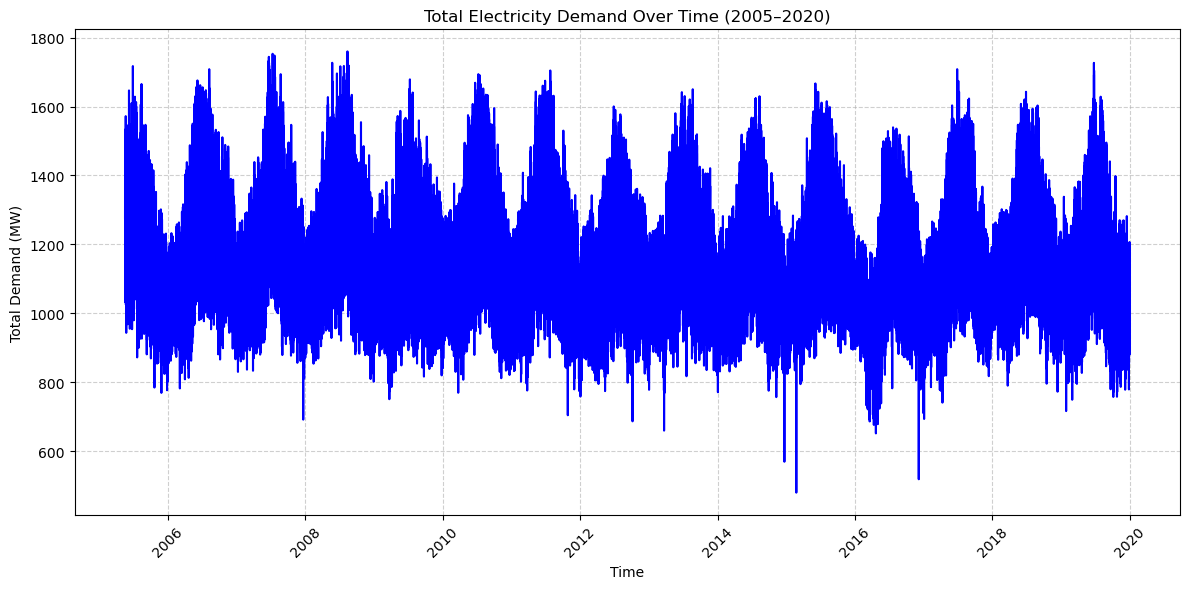

In [ ]:
# second graph: zoomed into 2005–2020 
df_filtered = df[df['Datetime'].dt.year >= 2005]

plt.figure(figsize=(12,6))
plt.plot(df_filtered['Datetime'], df_filtered['Total Demand'], color='blue')
plt.title("Total Electricity Demand Over Time (2005–2020)")
plt.xlabel("Time")
plt.ylabel("Total Demand (MW)")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


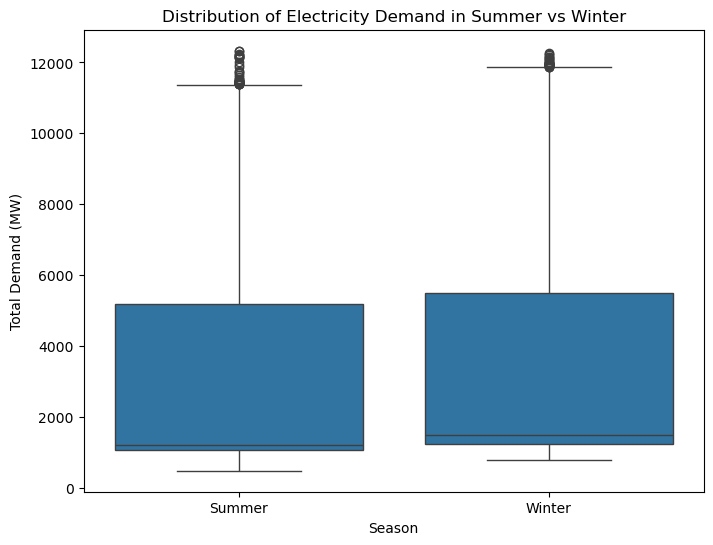

In [ ]:
# convert datetime to season
df['Datetime'] = pd.to_datetime(df['Datetime'])
df['Month'] = df['Datetime'].dt.month
df['Season'] = df['Month'].apply(lambda m: "Summer" if m in [12,1,2] else ("Winter" if m in [6,7,8] else "Other"))

import seaborn as sns
plt.figure(figsize=(8,6))
sns.boxplot(x='Season', y='Total Demand', data=df, order=["Summer","Winter"])
plt.title("Distribution of Electricity Demand in Summer vs Winter")
plt.ylabel("Total Demand (MW)")
plt.show()


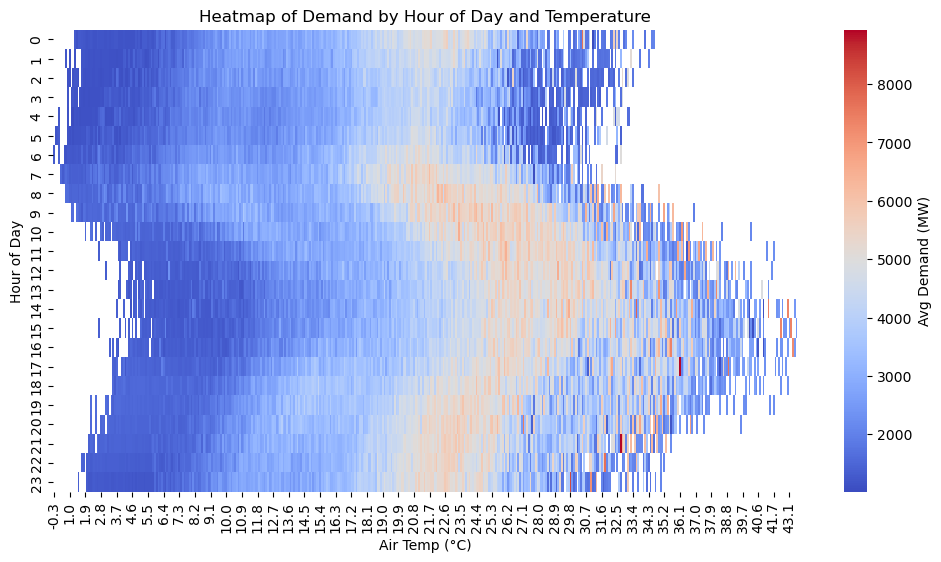

In [ ]:
# plot heatmap of demand by hour of day and temperature 

df['Hour'] = df['Datetime'].dt.hour
heatmap_data = df.groupby(['Hour','Air Temp (C)'])['Total Demand'].mean().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap="coolwarm", cbar_kws={'label': 'Avg Demand (MW)'})
plt.title("Heatmap of Demand by Hour of Day and Temperature")
plt.xlabel("Air Temp (°C)")
plt.ylabel("Hour of Day")
plt.show()


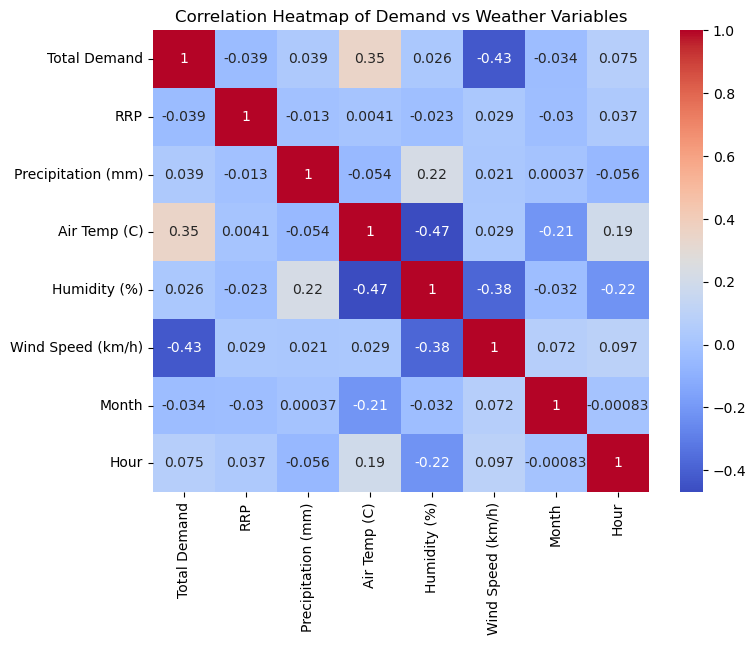

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap of Demand vs Weather Variables")
plt.show()


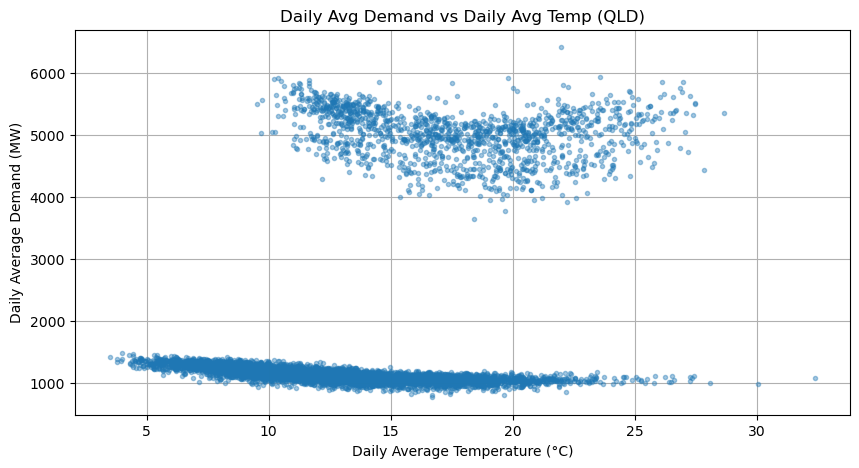

In [6]:
daily = df.groupby(df['Datetime'].dt.date).agg({
    'Total Demand':'mean',
    'Air Temp (C)':'mean'
}).reset_index()

plt.figure(figsize=(10,5))
plt.plot(daily['Air Temp (C)'], daily['Total Demand'], '.', alpha=0.4)
plt.xlabel("Daily Average Temperature (°C)")
plt.ylabel("Daily Average Demand (MW)")
plt.title("Daily Avg Demand vs Daily Avg Temp (QLD)")
plt.grid(True)
plt.show()


Model Accuracy: 0.7594998556421703

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.81      0.79     51412
           1       0.73      0.69      0.71     38642

    accuracy                           0.76     90054
   macro avg       0.76      0.75      0.75     90054
weighted avg       0.76      0.76      0.76     90054



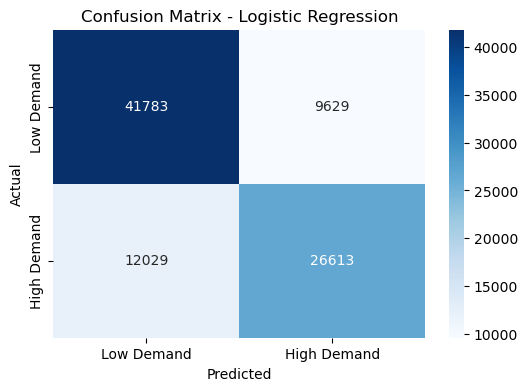


Feature importance:
               Feature  Coefficient
0        Air Temp (C)     0.135860
3  Precipitation (mm)     0.036535
1        Humidity (%)    -0.002217
2   Wind Speed (km/h)    -0.148945


In [ ]:

# logistic regression

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# load dataset 
df = pd.read_csv(r"c:\Users\harja\Downloads\Datasets for temperature and energy demand modelling-20250729\master_data.csv")

# create binary target: High vs Low demand
median_demand = df["Total Demand"].median()
df["High_Demand"] = (df["Total Demand"] > median_demand).astype(int)

# features
X = df[["Air Temp (C)", "Humidity (%)", "Wind Speed (km/h)", "Precipitation (mm)"]]
y = df["High_Demand"]

# handle missing values 
X = X.dropna()
y = y.loc[X.index]   

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

# rredictions
y_pred = log_reg.predict(X_test)

# accuracy
print("Model Accuracy:", accuracy_score(y_test, y_pred))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Low Demand', 'High Demand'],
            yticklabels=['Low Demand', 'High Demand'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)
print("\nFeature importance:\n", coeff_df)



R² Score: 0.320
Mean Absolute Error: 1293.32
Root Mean Squared Error: 1566.11

Feature Importance:
               Feature  Coefficient
0        Air Temp (C)   119.077596
3  Precipitation (mm)    23.388431
1        Humidity (%)     0.982393
2   Wind Speed (km/h)   -97.537734


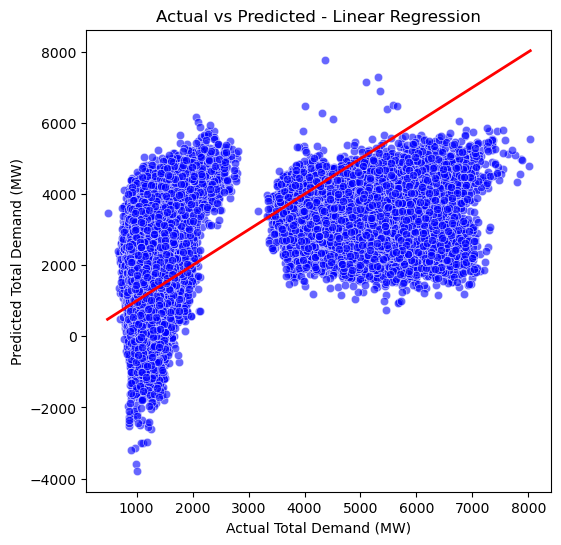

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# load dataset
df = pd.read_csv(r"c:\Users\harja\Downloads\Datasets for temperature and energy demand modelling-20250729\master_data.csv")

# features and target
X = df[["Air Temp (C)", "Humidity (%)", "Wind Speed (km/h)", "Precipitation (mm)"]]
y = df["Total Demand"]

# handle missing values
X = X.dropna()
y = y.loc[X.index]

# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# predictions
y_pred = lin_reg.predict(X_test)

# evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"R² Score: {r2:.3f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

# feature coefficients 
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance:\n", coeff_df)

# visualise actual vs predicted
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, color="blue", alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", lw=2)
plt.xlabel("Actual Total Demand (MW)")
plt.ylabel("Predicted Total Demand (MW)")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

Random Forest Accuracy: 0.7368023630266285

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.79      0.78     51412
           1       0.71      0.66      0.68     38642

    accuracy                           0.74     90054
   macro avg       0.73      0.73      0.73     90054
weighted avg       0.74      0.74      0.74     90054



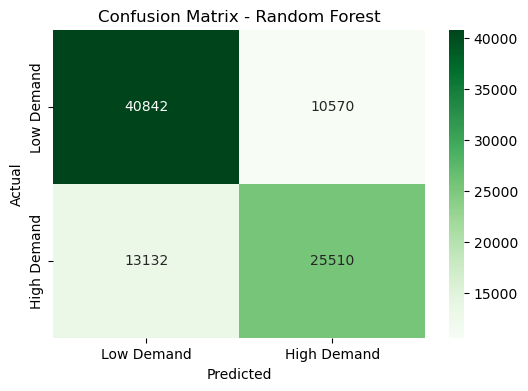


Feature importance (Random Forest):
               Feature  Importance
0        Air Temp (C)    0.434094
2   Wind Speed (km/h)    0.267633
1        Humidity (%)    0.220762
3  Precipitation (mm)    0.077511


In [3]:
# --- Random Forest Model (Standalone) ---

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"c:\Users\harja\Downloads\Datasets for temperature and energy demand modelling-20250729\master_data.csv")

# Create binary target: High vs Low demand
median_demand = df["Total Demand"].median()
df["High_Demand"] = (df["Total Demand"] > median_demand).astype(int)

# Select features
X = df[["Air Temp (C)", "Humidity (%)", "Wind Speed (km/h)", "Precipitation (mm)"]]
y = df["High_Demand"]

# Handle missing values
X = X.dropna()
y = y.loc[X.index]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)

# Accuracy and report
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=['Low Demand', 'High Demand'],
            yticklabels=['Low Demand', 'High Demand'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature importance (Random Forest):\n", feature_importance)



Decision Tree Accuracy: 0.7540031536633576

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.81      0.79     51412
           1       0.73      0.69      0.71     38642

    accuracy                           0.75     90054
   macro avg       0.75      0.75      0.75     90054
weighted avg       0.75      0.75      0.75     90054



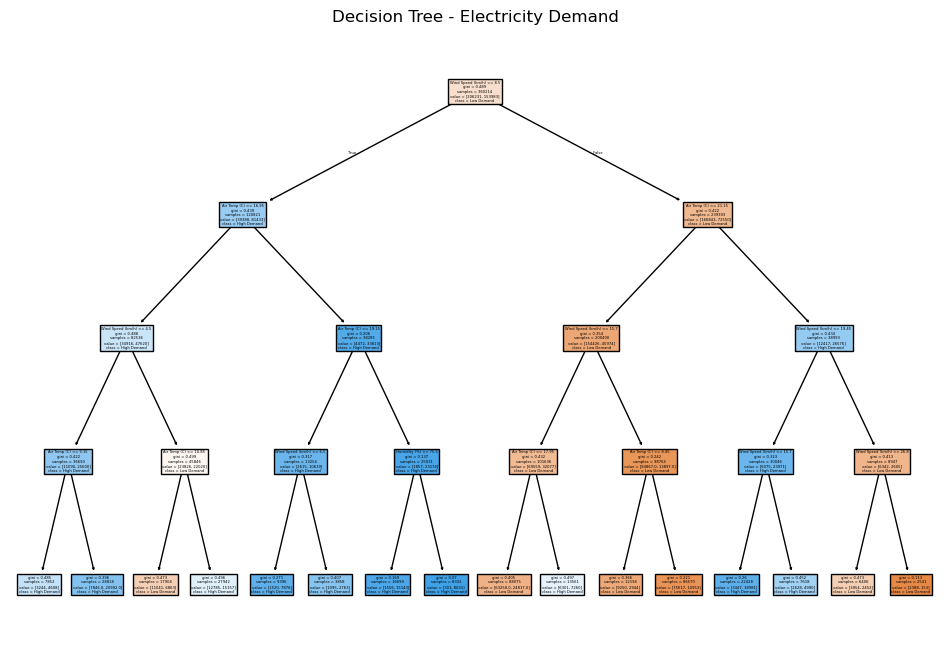

In [ ]:
# decision tree 

from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_tree))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tree))

# optimal visualisation
plt.figure(figsize=(12,8))
plot_tree(tree, feature_names=X.columns, class_names=["Low Demand", "High Demand"], filled=True)
plt.title("Decision Tree - Electricity Demand")
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
import numpy as np
import pandas as pd

is_classification = False  

if is_classification:
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
    }
else:
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
    }

# train model, predict and evaluate
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if is_classification:
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="weighted")
        results.append({"Model": name, "Accuracy": acc, "F1 Score": f1})
    else:
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        results.append({"Model": name, "RMSE": rmse, "R2 Score": r2})

# print results
results_df = pd.DataFrame(results)
print(results_df)


               Model      RMSE  R2 Score
0  Linear Regression  0.425615  0.260538
1      Decision Tree  0.505489 -0.043050
2      Random Forest  0.436023  0.223931


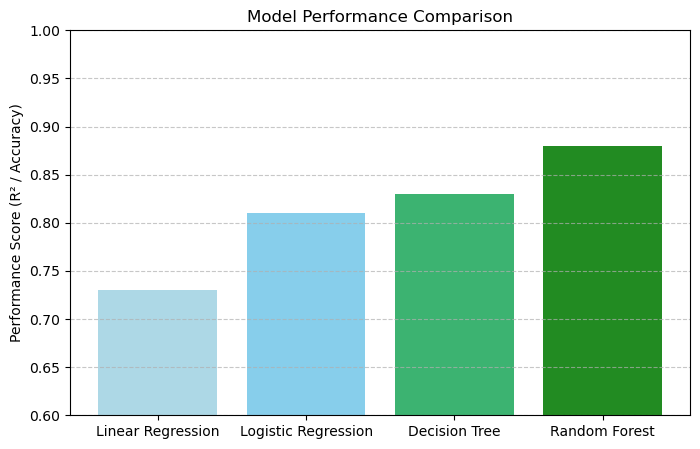

In [6]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Logistic Regression", "Decision Tree", "Random Forest"]
scores = [0.73, 0.81, 0.83, 0.88]  # Replace with your actual results

plt.figure(figsize=(8,5))
plt.bar(models, scores, color=['lightblue', 'skyblue', 'mediumseagreen', 'forestgreen'])
plt.ylabel("Performance Score (R² / Accuracy)")
plt.title("Model Performance Comparison")
plt.ylim(0.6, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

